**1) Imports and Basic Setup**

1.1 Install required libraries

In [1]:
!pip install pandas numpy scikit-learn xgboost ctgan category_encoders
!pip -q install catboost
!pip -q install tensorflow
!pip -q install autogluon.tabular
!pip -q install optuna
!pip install shap
!pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.6/227.6 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.9/98.9 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 81.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 

1.2 Import Python packages

In [2]:
import re
import numpy as np
import pandas as pd

import tensorflow as tf

from ctgan import CTGAN
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
# from lightgbm import LGBMClassifier

from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import roc_auc_score, f1_score, classification_report, average_precision_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import category_encoders as ce
import optuna
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve
import ipywidgets as widgets
from IPython.display import display, Markdown, clear_output
from sklearn.metrics import confusion_matrix

**2) Load Dataset**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# DATA_PATH = '/content/drive/MyDrive/Generative_Adversarial_Networks_for_Customer_Churn_Prediction_Research_Project_DataSet/Research_Project_Sample_Data.csv'

DATA_PATH = '/content/drive/MyDrive/Generative_Adversarial_Networks_for_Customer_Churn_Prediction_Research_Project_DataSet/Research_Project_NEW_2026_04_01.csv'

df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print(df_raw.head())
print(df_raw.shape)

  SERVICE_NAME     MSISDN  2025-05 2025-05 CS  2025-06 2025-06 CS  2025-07  \
0       MYBIDS  740019850     30.0  NON-CHURN     24.0  NON-CHURN     12.0   
1       MYBIDS  740025645    180.0  NON-CHURN    186.0  NON-CHURN    180.0   
2       MYBIDS  740030992    186.0  NON-CHURN    180.0  NON-CHURN    186.0   
3       MYBIDS  740034745    102.0  NON-CHURN    120.0  NON-CHURN     54.0   
4       MYBIDS  740040473     24.0  NON-CHURN     60.0  NON-CHURN     54.0   

  2025-07 CS  2025-08 2025-08 CS  ...  2025-10 2025-10 CS  2025-11 2025-11 CS  \
0  NON-CHURN     12.0  NON-CHURN  ...     12.0      CHURN      0.0        NaN   
1  NON-CHURN    186.0  NON-CHURN  ...    180.0  NON-CHURN    186.0  NON-CHURN   
2  NON-CHURN    186.0  NON-CHURN  ...    186.0  NON-CHURN    180.0  NON-CHURN   
3  NON-CHURN     30.0  NON-CHURN  ...     30.0      CHURN      0.0        NaN   
4  NON-CHURN     66.0  NON-CHURN  ...     48.0  NON-CHURN     18.0  NON-CHURN   

   2025-12 2025-12 CS  2026-01 2026-01 CS   

**3) Data Formatting and Reshaping**

3.1 Identify monthly spend columns and churn status columns

In [5]:
# Unpivot preserving SERVICE_NAME
spend_cols = [c for c in df_raw.columns if re.match(r"\d{4}-\d{2}$", c)]
churn_cols = [c for c in df_raw.columns if re.match(r"\d{4}-\d{2}\s+CS$", c)]


3.2 Unpivot spend and churn tables separately

In [6]:
df_spend = df_raw.melt(
    id_vars=['MSISDN','SERVICE_NAME'],
    value_vars=spend_cols,
    var_name='MONTH',
    value_name='tot_amount_w_tax'
)

df_churn = df_raw.melt(
    id_vars=['MSISDN','SERVICE_NAME'],
    value_vars=churn_cols,
    var_name='MONTH_CS',
    value_name='CHURN_STATUS'
)


3.3 Clean churn month label and merge spend + churn

In [7]:
df_churn['MONTH'] = df_churn['MONTH_CS'].str.replace(r"\s+CS$","",regex=True)
df_churn.drop(columns=['MONTH_CS'], inplace=True)

df_long = df_spend.merge(df_churn,on=['MSISDN','SERVICE_NAME','MONTH'],how='left')
df_long['MONTH_PRD'] = pd.to_datetime(df_long['MONTH']).dt.to_period('M')
df_long.drop(columns=['MONTH'], inplace=True)
df_long = df_long.sort_values(['MSISDN','MONTH_PRD']).reset_index(drop=True)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)

print(df_long.head(20))
print("Final behavioural table shape:", df_long.shape)


       MSISDN                    SERVICE_NAME    tot_amount_w_tax        CHURN_STATUS MONTH_PRD
0   740013413  NETH FM LAKSHAPATHI WARAMA IVR               144.0           NON-CHURN   2025-05
1   740013413  NETH FM LAKSHAPATHI WARAMA IVR               144.0           NON-CHURN   2025-06
2   740013413  NETH FM LAKSHAPATHI WARAMA IVR               150.0           NON-CHURN   2025-07
3   740013413  NETH FM LAKSHAPATHI WARAMA IVR               132.0           NON-CHURN   2025-08
4   740013413  NETH FM LAKSHAPATHI WARAMA IVR                90.0           NON-CHURN   2025-09
5   740013413  NETH FM LAKSHAPATHI WARAMA IVR                90.0           NON-CHURN   2025-10
6   740013413  NETH FM LAKSHAPATHI WARAMA IVR               156.0           NON-CHURN   2025-11
7   740013413  NETH FM LAKSHAPATHI WARAMA IVR                36.0           NON-CHURN   2025-12
8   740013413  NETH FM LAKSHAPATHI WARAMA IVR               168.0           NON-CHURN   2026-01
9   740013413  NETH FM LAKSHAPATHI WARAM

**4) Cleaning Spend + Create Churn Flag**

4.1 Convert spend to numeric and fill missing with 0

In [8]:
# Force numeric for spend
df_long['tot_amount_w_tax'] = pd.to_numeric(df_long['tot_amount_w_tax'], errors='coerce')
df_long['tot_amount_w_tax'] = df_long['tot_amount_w_tax'].fillna(0)

4.2 Map churn status text → churn_flag (1/0)

In [9]:
# churn_flag
def map_churn_status(val):
    if pd.isna(val): return np.nan
    s=str(val).strip().upper()
    if s=='CHURN': return 1
    if s in ['NON-CHURN','NON CHURN']: return 0
    return np.nan

df_long['churn_flag']=df_long['CHURN_STATUS'].apply(map_churn_status)

**5) Remove Post-Churn Months (Keep only up to first churn month)**

5.1 Find first churn month per MSISDN and filter timeline

In [10]:
# remove post-churn months
first_churn=(df_long[df_long.churn_flag==1]
             .groupby('MSISDN')['MONTH_PRD'].min().rename('first_churn_month'))

df_long=df_long.merge(first_churn,on='MSISDN',how='left')

df_long=df_long[df_long.first_churn_month.isna()|
                (df_long.MONTH_PRD<=df_long.first_churn_month)]

df_long.drop(columns=['first_churn_month'],inplace=True)


**6) Service-Level Churn Risk Feature**

6.1 Compute churn rate per service and merge

In [11]:
# service churn rate
scr=(df_long[df_long.churn_flag.isin([0,1])]
     .groupby('SERVICE_NAME')['churn_flag'].mean()
     .rename('service_churn_rate').reset_index())

gmean=scr.service_churn_rate.mean()
df_long=df_long.merge(scr,on='SERVICE_NAME',how='left')
df_long['service_churn_rate']=df_long['service_churn_rate'].fillna(gmean)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)

print(df_long.head(20))
print("Final behavioural table shape:", df_long.shape)

       MSISDN                    SERVICE_NAME  tot_amount_w_tax        CHURN_STATUS MONTH_PRD  churn_flag  service_churn_rate
0   740013413  NETH FM LAKSHAPATHI WARAMA IVR             144.0           NON-CHURN   2025-05         0.0            0.050635
1   740013413  NETH FM LAKSHAPATHI WARAMA IVR             144.0           NON-CHURN   2025-06         0.0            0.050635
2   740013413  NETH FM LAKSHAPATHI WARAMA IVR             150.0           NON-CHURN   2025-07         0.0            0.050635
3   740013413  NETH FM LAKSHAPATHI WARAMA IVR             132.0           NON-CHURN   2025-08         0.0            0.050635
4   740013413  NETH FM LAKSHAPATHI WARAMA IVR              90.0           NON-CHURN   2025-09         0.0            0.050635
5   740013413  NETH FM LAKSHAPATHI WARAMA IVR              90.0           NON-CHURN   2025-10         0.0            0.050635
6   740013413  NETH FM LAKSHAPATHI WARAMA IVR             156.0           NON-CHURN   2025-11         0.0            0

6.2 Remove the 2025-12 month (hard filter)

In [12]:
# df_long = df_long[df_long['MONTH_PRD'] != pd.Period('2025-12', freq='M')] Dataset Change
# df_long = df_long[df_long['MONTH_PRD'] != pd.Period('2025-12', freq='M')] Remove 5th month also make data set chancange not -1 month on month

# df_long = df_long[df_long['MONTH_PRD'] != pd.Period('2026-02', freq='M')]

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)

print(df_long.head(20))
print("Final behavioural table shape:", df_long.shape)

       MSISDN                    SERVICE_NAME  tot_amount_w_tax        CHURN_STATUS MONTH_PRD  churn_flag  service_churn_rate
0   740013413  NETH FM LAKSHAPATHI WARAMA IVR             144.0           NON-CHURN   2025-05         0.0            0.050635
1   740013413  NETH FM LAKSHAPATHI WARAMA IVR             144.0           NON-CHURN   2025-06         0.0            0.050635
2   740013413  NETH FM LAKSHAPATHI WARAMA IVR             150.0           NON-CHURN   2025-07         0.0            0.050635
3   740013413  NETH FM LAKSHAPATHI WARAMA IVR             132.0           NON-CHURN   2025-08         0.0            0.050635
4   740013413  NETH FM LAKSHAPATHI WARAMA IVR              90.0           NON-CHURN   2025-09         0.0            0.050635
5   740013413  NETH FM LAKSHAPATHI WARAMA IVR              90.0           NON-CHURN   2025-10         0.0            0.050635
6   740013413  NETH FM LAKSHAPATHI WARAMA IVR             156.0           NON-CHURN   2025-11         0.0            0

**7) Feature Engineering (Lag, Trend, Activity)**

7.1 Create lag spend features (last 1/2/3 months)

In [13]:
#Lag spend features
df_long = df_long.sort_values(['MSISDN','MONTH_PRD'])
for i in [1,2,3]:
    df_long[f'spend_lag_{i}'] = df_long.groupby('MSISDN')['tot_amount_w_tax'].shift(i)

lag_cols = ['spend_lag_1','spend_lag_2','spend_lag_3']
df_long[lag_cols] = df_long[lag_cols].fillna(0).astype(float)

7.2 Trend ratio + volatility + continuous engagement features

In [14]:
#Trend, volatility & engagement continuity
df_long['spend_avg_last3'] = df_long[lag_cols].replace(0,np.nan).mean(axis=1)
df_long['spend_std_last3'] = df_long[lag_cols].replace(0,np.nan).std(axis=1)

df_long['spend_trend_ratio'] = (
    df_long['tot_amount_w_tax'] / df_long['spend_avg_last3']
).replace([np.inf,-np.inf],np.nan).fillna(0)

df_long['active_flag'] = (df_long['tot_amount_w_tax'] > 0).astype(int)

df_long['consecutive_active_months'] = (
    df_long.groupby('MSISDN')['active_flag']
    .apply(lambda x: x.groupby((x!=x.shift()).cumsum()).cumcount()+1)
    .reset_index(level=0,drop=True)
)

**8) aWOE Encoding of Service Risk**

8.1 Fit aWOE encoder on service churn-rate bins

In [15]:
#WOE encoding of service risk
#import category_encoders as ce
train_woe = df_long[df_long['churn_flag'].isin([0,1])].copy()
train_woe['service_risk_bin'] = pd.qcut(
    train_woe['service_churn_rate'], q=5, duplicates='drop'
)

woe_encoder = ce.WOEEncoder(cols=['service_risk_bin'])

train_woe['service_risk_woe'] = woe_encoder.fit_transform(
    train_woe[['service_risk_bin']], train_woe['churn_flag']
)['service_risk_bin']


8.2 Apply the WOE transformation to full dataset

In [16]:
df_long['service_risk_bin'] = pd.cut(
    df_long['service_churn_rate'],
    bins=train_woe['service_risk_bin'].cat.categories
)

df_long['service_risk_woe'] = woe_encoder.transform(
    df_long[['service_risk_bin']]
)['service_risk_bin'].fillna(0)

8.3 Display dataset snapshot

In [17]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)

print(df_long.head(20))
print("Final behavioural table shape:", df_long.shape)

       MSISDN                    SERVICE_NAME  tot_amount_w_tax        CHURN_STATUS MONTH_PRD  churn_flag  service_churn_rate  spend_lag_1  spend_lag_2  spend_lag_3  spend_avg_last3  spend_std_last3  spend_trend_ratio  active_flag  consecutive_active_months  service_risk_bin  service_risk_woe
0   740013413  NETH FM LAKSHAPATHI WARAMA IVR             144.0           NON-CHURN   2025-05         0.0            0.050635          0.0          0.0          0.0              NaN              NaN           0.000000            1                          1  (0.0506, 0.0521]          0.063736
1   740013413  NETH FM LAKSHAPATHI WARAMA IVR             144.0           NON-CHURN   2025-06         0.0            0.050635        144.0          0.0          0.0            144.0              NaN           1.000000            1                          2  (0.0506, 0.0521]          0.063736
2   740013413  NETH FM LAKSHAPATHI WARAMA IVR             150.0           NON-CHURN   2025-07         0.0            0

8.4 Download Customer Behavioural Table

In [18]:
df_long.to_excel("final_behavioural_table.xlsx", index=False)
print("File saved: final_behavioural_table.xlsx")

File saved: final_behavioural_table.xlsx


**9) Basic Data Cleaning & Type Fixes for Model Features**

9.1 Define features and force numeric types

In [19]:
features = [
    'tot_amount_w_tax','spend_lag_1','spend_lag_2','spend_lag_3',
    'spend_avg_last3','spend_std_last3','spend_trend_ratio',
    'consecutive_active_months','service_risk_woe'
]

# Force all features to numeric
for col in features:
    df_long[col] = pd.to_numeric(df_long[col], errors='coerce')

df_long[features] = df_long[features].fillna(0)

**10) Split Training vs Scoring Sets**

10.1 Separate labeled vs unlabeled churn rows

In [20]:
# Split training vs scoring
train_df = df_long[df_long['churn_flag'].isin([0,1])].copy()
score_df = df_long[df_long['churn_flag'].isna()].copy()

10.2 Restrict scoring to “DATA NOT AVAILABLE”

In [21]:
# Optional: keep only target months to score (e.g., 2025-11)
score_df = score_df.sort_values(["MSISDN","MONTH_PRD"])
# If multiple months exist, keep latest per MSISDN
score_df = score_df.groupby("MSISDN").tail(1)

10.3 Create snapshot tables (for CTGAN + final scoring consistency)

In [22]:
train_df_snap = (
    train_df.sort_values(["MSISDN","MONTH_PRD"])
    .groupby("MSISDN").tail(1)
    .copy()
)

score_df_snap = (
    score_df.sort_values(["MSISDN","MONTH_PRD"])
    .groupby("MSISDN").tail(1)
    .copy()
)

10.4 Quick check counts

In [23]:
print("train_df:", train_df.shape, " labeled rate:", train_df["churn_flag"].mean())
print("score_df:", score_df.shape, " months:", score_df["MONTH_PRD"].unique())

train_df: (66308, 17)  labeled rate: 0.0491041804910418
score_df: (4671, 17)  months: <PeriodArray>
['2026-02']
Length: 1, dtype: period[M]


**11) Sanity Check Setup for Two Approaches (Common Split + Helper)**

11.1 Train/validation split (same as your current one)

In [24]:
# (keep your features list as-is)
X = train_df[features].copy()
y = train_df['churn_flag'].astype(int).copy()

# IMPORTANT: split by customer so same MSISDN is not in both train & val
groups = train_df['MSISDN'].copy()

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_idx, val_idx = next(gss.split(X, y, groups=groups))

X_tr, X_val = X.iloc[tr_idx].copy(), X.iloc[val_idx].copy()
y_tr, y_val = y.iloc[tr_idx].copy(), y.iloc[val_idx].copy()

11.2 Helper: threshold search + metric storage (reusable for all models)

In [25]:
def evaluate_with_best_threshold(model_name, model, X_tr, y_tr, X_val, y_val):
    # Fit
    model.fit(X_tr, y_tr)

    # Probabilities / scores
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_val)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_val)
        # scale decision scores to 0-1 safely
        denom = (y_score.max() - y_score.min())
        y_score = (y_score - y_score.min()) / (denom + 1e-9)
    else:
        raise ValueError(f"{model_name} has neither predict_proba nor decision_function")

    # Threshold tuning for best F1
    thresholds = np.arange(0.05, 0.95, 0.01)
    f1_scores = [f1_score(y_val, (y_score > t).astype(int)) for t in thresholds]
    best_t = thresholds[int(np.argmax(f1_scores))]

    # Final predictions at best threshold
    y_pred = (y_score > best_t).astype(int)

    # Metrics
    # ROC-AUC may fail if validation has only one class
    try:
        auc = roc_auc_score(y_val, y_score)
    except ValueError:
        auc = np.nan

    pr_auc = average_precision_score(y_val, y_score)  # very useful for churn
    f1 = f1_score(y_val, y_pred)
    rep = classification_report(y_val, y_pred, output_dict=True, zero_division=0)

    churn_precision = rep["1"]["precision"]
    churn_recall = rep["1"]["recall"]

    print(f"\n[{model_name}] Best Threshold = {best_t:.2f}")
    print(f"[{model_name}] ROC-AUC = {auc:.6f} | PR-AUC = {pr_auc:.6f} | F1 = {f1:.6f}")
    print(f"[{model_name}] Report:\n", classification_report(y_val, y_pred, zero_division=0))

    return {
        "Model": model_name,
        "ROC_AUC": auc,
        "PR_AUC": pr_auc,
        "Best_Threshold": float(best_t),
        "Churn_Precision": churn_precision,
        "Churn_Recall": churn_recall,
        "F1": f1
    }, model, y_score, best_t

**12) Sanity Check Method: XGBoost**

12.1 XGBoost (Augmented) - Before CTGAN

In [26]:
if "results" not in globals():
    results = []          # list of metric rows
if "probs_store" not in globals():
    probs_store = {}      # saved predicted probabilities
if "models_store" not in globals():
    models_store = {}     # saved fitted models

# --- 1) Safe scale_pos_weight ---
pos = int((y_tr == 1).sum())
neg = int((y_tr == 0).sum())
pos = max(1, pos)  # avoid divide-by-zero
scale_w = neg / pos

# --- 2) Train + evaluate baseline XGBoost ---
xgb_model_pre = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_w,
    eval_metric="logloss", random_state=42, n_jobs=-1
)

xgb_metrics_pre, xgb_model_pre, xgb_prob_pre, xgb_best_t_pre = evaluate_with_best_threshold(
    "PRE_XGBoost", xgb_model_pre, X_tr, y_tr, X_val, y_val
)

# --- 3) Save outputs for comparison later (PRE vs POST-CTGAN) ---
results.append({
    "stage": "PRE_CTGAN",
    "model": "XGBoost",
    **xgb_metrics_pre,              # works if xgb_metrics_pre is a dict
    "best_threshold": xgb_best_t_pre,
    # "scale_pos_weight": scale_w
})

probs_store["PRE_CTGAN_XGBoost"] = xgb_prob_pre
models_store["PRE_CTGAN_XGBoost"] = xgb_model_pre

# --- 4) Quick view table ---
results_df = pd.DataFrame(results)
results_df



[PRE_XGBoost] Best Threshold = 0.77
[PRE_XGBoost] ROC-AUC = 0.924814 | PR-AUC = 0.348285 | F1 = 0.405669
[PRE_XGBoost] Report:
               precision    recall  f1-score   support

           0       0.98      0.91      0.94     12512
           1       0.29      0.66      0.41       692

    accuracy                           0.90     13204
   macro avg       0.64      0.79      0.68     13204
weighted avg       0.94      0.90      0.92     13204



,stage,model,Model,ROC_AUC,PR_AUC,Best_Threshold,Churn_Precision,Churn_Recall,F1,best_threshold
0,PRE_CTGAN,XGBoost,PRE_XGBoost,0.924814,0.348285,0.77,0.292465,0.66185,0.405669,0.77


**13) Split REAL labeled data**

13.1 Create REAL labeled dataset (no NaNs in churn_flag)

In [27]:
real_df = df_long[df_long["churn_flag"].isin([0,1])].copy()

X_real = real_df[features].copy()
y_real = real_df["churn_flag"].astype(int).copy()

13.2 Split into REAL train/REAL validation (stratified)

In [28]:
X_tr_real, X_val_real, y_tr_real, y_val_real = train_test_split(
    X_real, y_real,
    test_size=0.2,
    stratify=y_real,
    random_state=42
)

13.3 Quick sanity check (recommended)

In [29]:
print("REAL train distribution:\n", y_tr_real.value_counts())
print("REAL val distribution:\n", y_val_real.value_counts())

REAL train distribution:
 churn_flag
0    50441
1     2605
Name: count, dtype: int64
REAL val distribution:
 churn_flag
0    12611
1      651
Name: count, dtype: int64


**14) Re-Train Both Methods on CTGAN-Augmented Data**

14.1 Generate synthetic churners only to balance TRAINING **split**

In [30]:
ctgan_train = X_tr.copy()
ctgan_train["churn_flag"] = y_tr.values

# Train CTGAN only on churners (minority)
churn_train = ctgan_train[ctgan_train["churn_flag"] == 1].drop(columns=["churn_flag"])

ctgan = CTGAN(epochs=300, verbose=True)
ctgan.fit(churn_train, discrete_columns=[])

# how many synthetic churners to add (balance 1:1)
n_pos = int((y_tr == 1).sum())
n_neg = int((y_tr == 0).sum())
n_synth = max(0, n_neg - n_pos)

# (optional safety cap so you don't generate a crazy amount)
n_synth = min(n_synth, 3 * n_pos)  # try 1*n_pos, 2*n_pos, 3*n_pos

print("Synthetic churners to generate:", n_synth)

synthetic_X = ctgan.sample(n_synth)
synthetic_y = pd.Series(np.ones(n_synth, dtype=int), name="churn_flag")

# Augmented train set
X_tr_aug = pd.concat([X_tr.reset_index(drop=True), synthetic_X.reset_index(drop=True)], ignore_index=True)
y_tr_aug = pd.concat([y_tr.reset_index(drop=True), synthetic_y], ignore_index=True)

Gen. (-02.49) | Discrim. (+00.07): 100%|██████████| 300/300 [01:46<00:00,  2.81it/s]

Synthetic churners to generate: 7692


**15) Method A on Augmented Data: XGBoost + RandomForest**

15.1 XGBoost (Augmented) - AFter CTGAN

In [31]:
if "results" not in globals():
    results = []
if "probs_store" not in globals():
    probs_store = {}
if "models_store" not in globals():
    models_store = {}

# Use REAL validation set variables (same logic as RF block)
X_val_used = X_val if "X_val_real" not in globals() else X_val_real
y_val_used = y_val if "y_val_real" not in globals() else y_val_real

xgb_aug = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_metrics_post, xgb_model_post, xgb_prob_post, xgb_best_t_post = evaluate_with_best_threshold(
    "POST_CTGAN_XGBoost", xgb_aug, X_tr_aug, y_tr_aug, X_val_used, y_val_used
)

results.append({
    "stage": "POST_CTGAN",
    "model": "XGBoost",
    **xgb_metrics_post,
    "best_threshold": xgb_best_t_post
})

probs_store["POST_CTGAN_XGBoost"] = xgb_prob_post
models_store["POST_CTGAN_XGBoost"] = xgb_model_post

# --- View table ---
results_df = pd.DataFrame(results).sort_values(["model", "stage"])
results_df


[POST_CTGAN_XGBoost] Best Threshold = 0.25
[POST_CTGAN_XGBoost] ROC-AUC = 0.929210 | PR-AUC = 0.375802 | F1 = 0.418782
[POST_CTGAN_XGBoost] Report:
               precision    recall  f1-score   support

           0       0.97      0.95      0.96     12611
           1       0.36      0.51      0.42       651

    accuracy                           0.93     13262
   macro avg       0.67      0.73      0.69     13262
weighted avg       0.94      0.93      0.94     13262



,stage,model,Model,ROC_AUC,PR_AUC,Best_Threshold,Churn_Precision,Churn_Recall,F1,best_threshold
1,POST_CTGAN,XGBoost,POST_CTGAN_XGBoost,0.929210,0.375802,0.25,0.356757,0.506912,0.418782,0.25
0,PRE_CTGAN,XGBoost,PRE_XGBoost,0.924814,0.348285,0.77,0.292465,0.661850,0.405669,0.77


15.2 XGBoost (Comparison) After CTGAN

In [32]:
X_val_used = X_val if "X_val_real" not in globals() else X_val_real
y_val_used = y_val if "y_val_real" not in globals() else y_val_real

# Recompute probs on the SAME validation set (avoids length mismatch)
xgb_prob_pre_cmp  = xgb_model_pre.predict_proba(X_val_used)[:, 1]
xgb_prob_post_cmp = xgb_model_post.predict_proba(X_val_used)[:, 1]

# Predictions using best thresholds
y_pred_pre  = (xgb_prob_pre_cmp  >= xgb_best_t_pre).astype(int)
y_pred_post = (xgb_prob_post_cmp >= xgb_best_t_post).astype(int)

rep_pre  = classification_report(y_val_used, y_pred_pre, output_dict=True, zero_division=0)
rep_post = classification_report(y_val_used, y_pred_post, output_dict=True, zero_division=0)

comparison = pd.DataFrame({
    "Model": ["XGBoost_PRE_CTGAN", "XGBoost_POST_CTGAN"],
    "ROC_AUC": [
        xgb_metrics_pre.get("ROC_AUC", xgb_metrics_pre.get("AUC", xgb_metrics_pre.get("auc"))),
        xgb_metrics_post.get("ROC_AUC", xgb_metrics_post.get("AUC", xgb_metrics_post.get("auc")))
    ],
    "Best_Threshold": [xgb_best_t_pre, xgb_best_t_post],
    "Churn_Precision": [rep_pre["1"]["precision"], rep_post["1"]["precision"]],
    "Churn_Recall":    [rep_pre["1"]["recall"],    rep_post["1"]["recall"]],
    "F1": [
        xgb_metrics_pre.get("F1", xgb_metrics_pre.get("f1")),
        xgb_metrics_post.get("F1", xgb_metrics_post.get("f1"))
    ]
})

print(comparison)

best_row = comparison.sort_values(["ROC_AUC", "F1"], ascending=False).iloc[0]
print("\nBEST (by ROC_AUC then F1):", best_row["Model"])


                Model   ROC_AUC  Best_Threshold  Churn_Precision  Churn_Recall        F1
0   XGBoost_PRE_CTGAN  0.924814            0.77         0.298810      0.771121  0.405669
1  XGBoost_POST_CTGAN  0.929210            0.25         0.356757      0.506912  0.418782

BEST (by ROC_AUC then F1): XGBoost_POST_CTGAN


15.3 RandomForest (Augmented) - After CTGAN

In [33]:
# if "results" not in globals():
#     results = []
# if "probs_store" not in globals():
#     probs_store = {}
# if "models_store" not in globals():
#     models_store = {}

# # Use REAL validation set variables:
# # If you don't have X_val_real/y_val_real defined, replace with X_val/y_val.
# X_val_used = X_val if "X_val_real" not in globals() else X_val_real
# y_val_used = y_val if "y_val_real" not in globals() else y_val_real

# rf_aug = RandomForestClassifier(
#     n_estimators=500,
#     max_depth=10,
#     min_samples_leaf=50,
#     class_weight="balanced",
#     random_state=42,
#     n_jobs=-1
# )

# rf_metrics_post, rf_model_post, rf_prob_post, rf_best_t_post = evaluate_with_best_threshold(
#     "POST_CTGAN_RandomForest", rf_aug, X_tr_aug, y_tr_aug, X_val_used, y_val_used
# )

# results.append({
#     "stage": "POST_CTGAN",
#     "model": "RandomForest",
#     **rf_metrics_post,
#     "best_threshold": rf_best_t_post
# })

# probs_store["POST_CTGAN_RandomForest"] = rf_prob_post
# models_store["POST_CTGAN_RandomForest"] = rf_model_post

# # --- View table ---
# results_df = pd.DataFrame(results).sort_values(["model", "stage"])
# results_df

15.4 ANN (MLP) with scaling (Augmented) _ After CTGAN

In [34]:
# if "results" not in globals():
#     results = []
# if "probs_store" not in globals():
#     probs_store = {}
# if "models_store" not in globals():
#     models_store = {}

# # Use REAL validation set variables:
# # If you don't have X_val_real/y_val_real defined, it will fallback to X_val/y_val.
# X_val_used = X_val if "X_val_real" not in globals() else X_val_real
# y_val_used = y_val if "y_val_real" not in globals() else y_val_real

# ann_aug = Pipeline(steps=[
#     ("scaler", StandardScaler()),
#     ("mlp", MLPClassifier(
#         hidden_layer_sizes=(64, 32),
#         activation="relu",
#         solver="adam",
#         alpha=0.0005,
#         learning_rate_init=0.001,
#         max_iter=300,
#         random_state=42
#     ))
# ])

# ann_metrics_post, ann_model_post, ann_prob_post, ann_best_t_post = evaluate_with_best_threshold(
#     "POST_CTGAN_ANN_MLP", ann_aug, X_tr_aug, y_tr_aug, X_val_used, y_val_used
# )

# results.append({
#     "stage": "POST_CTGAN",
#     "model": "ANN_MLP",
#     **ann_metrics_post,
#     "best_threshold": ann_best_t_post
# })

# probs_store["POST_CTGAN_ANN_MLP"] = ann_prob_post
# models_store["POST_CTGAN_ANN_MLP"] = ann_model_post

# # --- View table ---
# results_df = pd.DataFrame(results).sort_values(["model", "stage"])
# results_df

15.5 CatBoost (Augmented) _ After CTGAN

In [35]:
if "results" not in globals():
    results = []
if "probs_store" not in globals():
    probs_store = {}
if "models_store" not in globals():
    models_store = {}

# Use REAL validation set variables
X_val_used = X_val if "X_val_real" not in globals() else X_val_real
y_val_used = y_val if "y_val_real" not in globals() else y_val_real

cat_aug = CatBoostClassifier(
    iterations=1200,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=False
)

cat_metrics_post, cat_model_post, cat_prob_post, cat_best_t_post = evaluate_with_best_threshold(
    "POST_CTGAN_CatBoost", cat_aug, X_tr_aug, y_tr_aug, X_val_used, y_val_used
)

# --- Save outputs ---
results.append({
    "stage": "POST_CTGAN",
    "model": "CatBoost",
    **cat_metrics_post,
    "best_threshold": cat_best_t_post
})

probs_store["POST_CTGAN_CatBoost"] = cat_prob_post
models_store["POST_CTGAN_CatBoost"] = cat_model_post

# --- View table ---
results_df = pd.DataFrame(results).sort_values(["model", "stage"])
results_df


[POST_CTGAN_CatBoost] Best Threshold = 0.24
[POST_CTGAN_CatBoost] ROC-AUC = 0.953147 | PR-AUC = 0.567724 | F1 = 0.527778
[POST_CTGAN_CatBoost] Report:
               precision    recall  f1-score   support

           0       0.98      0.96      0.97     12611
           1       0.46      0.61      0.53       651

    accuracy                           0.95     13262
   macro avg       0.72      0.79      0.75     13262
weighted avg       0.95      0.95      0.95     13262



,stage,model,Model,ROC_AUC,PR_AUC,Best_Threshold,Churn_Precision,Churn_Recall,F1,best_threshold
2,POST_CTGAN,CatBoost,POST_CTGAN_CatBoost,0.953147,0.567724,0.24,0.463415,0.612903,0.527778,0.24
1,POST_CTGAN,XGBoost,POST_CTGAN_XGBoost,0.929210,0.375802,0.25,0.356757,0.506912,0.418782,0.25
0,PRE_CTGAN,XGBoost,PRE_XGBoost,0.924814,0.348285,0.77,0.292465,0.661850,0.405669,0.77


15.6 LSTM (Long Short-Term Memory) (Augmented) _ After CTGAN

In [36]:
# --- Ensure stores exist (safe to re-run) ---
if "results" not in globals():
    results = []
if "probs_store" not in globals():
    probs_store = {}
if "models_store" not in globals():
    models_store = {}

# Use REAL validation set variables
X_val_used = X_val if "X_val_real" not in globals() else X_val_real
y_val_used = y_val if "y_val_real" not in globals() else y_val_real


# ---- Wrapper so it works with evaluate_with_best_threshold (needs fit + predict_proba) ----
class TabularLSTMWrapper:
    def __init__(self, epochs=25, batch_size=256, lr=0.001, verbose=0):
        self.epochs = epochs
        self.batch_size = batch_size
        self.lr = lr
        self.verbose = verbose
        self.scaler = StandardScaler()
        self.model = None
        self.n_features_ = None

    def _build_model(self, n_features):
        model = tf.keras.Sequential([
            tf.keras.layers.Input(shape=(1, n_features)),
            tf.keras.layers.LSTM(64),
            tf.keras.layers.Dropout(0.2),
            tf.keras.layers.Dense(32, activation="relu"),
            tf.keras.layers.Dense(1, activation="sigmoid"),
        ])
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=self.lr),
            loss="binary_crossentropy"
        )
        return model

    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float32)
        y = np.asarray(y, dtype=np.int32)

        self.n_features_ = X.shape[1]

        # Scale tabular features
        Xs = self.scaler.fit_transform(X)

        # Convert to 1-step sequence: (N, 1, features)
        Xseq = Xs.reshape((Xs.shape[0], 1, Xs.shape[1]))

        self.model = self._build_model(self.n_features_)

        es = tf.keras.callbacks.EarlyStopping(
            monitor="loss", patience=3, restore_best_weights=True
        )

        self.model.fit(
            Xseq, y,
            epochs=self.epochs,
            batch_size=self.batch_size,
            verbose=self.verbose,
            callbacks=[es]
        )
        return self

    def predict_proba(self, X):
        X = np.asarray(X, dtype=np.float32)

        # Scale using training scaler
        Xs = self.scaler.transform(X)
        Xseq = Xs.reshape((Xs.shape[0], 1, Xs.shape[1]))

        p = self.model.predict(Xseq, verbose=0).reshape(-1)
        return np.column_stack([1 - p, p])


# --- Train + evaluate POST-CTGAN LSTM on augmented training data ---
lstm_aug = TabularLSTMWrapper(epochs=25, batch_size=256, lr=0.001, verbose=0)

lstm_metrics_post, lstm_model_post, lstm_prob_post, lstm_best_t_post = evaluate_with_best_threshold(
    "POST_CTGAN_LSTM", lstm_aug, X_tr_aug, y_tr_aug, X_val_used, y_val_used
)

# --- Save outputs
results.append({
    "stage": "POST_CTGAN",
    "model": "LSTM",
    **lstm_metrics_post,
    "best_threshold": lstm_best_t_post
})

probs_store["POST_CTGAN_LSTM"] = lstm_prob_post
models_store["POST_CTGAN_LSTM"] = lstm_model_post

# --- View table ---
results_df = pd.DataFrame(results).sort_values(["model", "stage"])
results_df


[POST_CTGAN_LSTM] Best Threshold = 0.21
[POST_CTGAN_LSTM] ROC-AUC = 0.915570 | PR-AUC = 0.296140 | F1 = 0.370495
[POST_CTGAN_LSTM] Report:
               precision    recall  f1-score   support

           0       0.97      0.94      0.95     12611
           1       0.29      0.51      0.37       651

    accuracy                           0.92     13262
   macro avg       0.63      0.72      0.66     13262
weighted avg       0.94      0.92      0.93     13262



,stage,model,Model,ROC_AUC,PR_AUC,Best_Threshold,Churn_Precision,Churn_Recall,F1,best_threshold
2,POST_CTGAN,CatBoost,POST_CTGAN_CatBoost,0.953147,0.567724,0.24,0.463415,0.612903,0.527778,0.24
3,POST_CTGAN,LSTM,POST_CTGAN_LSTM,0.915570,0.296140,0.21,0.292444,0.505376,0.370495,0.21
1,POST_CTGAN,XGBoost,POST_CTGAN_XGBoost,0.929210,0.375802,0.25,0.356757,0.506912,0.418782,0.25
0,PRE_CTGAN,XGBoost,PRE_XGBoost,0.924814,0.348285,0.77,0.292465,0.661850,0.405669,0.77


15.7 Temporal CNN (Augmented) _ After CTGAN

In [37]:
# --- Ensure stores exist (safe to re-run) ---
if "results" not in globals():
    results = []
if "probs_store" not in globals():
    probs_store = {}
if "models_store" not in globals():
    models_store = {}

# Use REAL validation set variables
X_val_used = X_val if "X_val_real" not in globals() else X_val_real
y_val_used = y_val if "y_val_real" not in globals() else y_val_real


# ---- Wrapper so it works with evaluate_with_best_threshold (needs fit + predict_proba) ----
class TabularTemporalCNNWrapper:
    def __init__(self, epochs=25, batch_size=256, lr=0.001, verbose=0):
        self.epochs = epochs
        self.batch_size = batch_size
        self.lr = lr
        self.verbose = verbose
        self.scaler = StandardScaler()
        self.model = None
        self.n_features_ = None

    def _build_model(self, n_features): # How model is build
        model = tf.keras.Sequential([
            tf.keras.layers.Input(shape=(1, n_features)),  # 1 timestep
            tf.keras.layers.Conv1D(filters=64, kernel_size=1, activation="relu"),
            tf.keras.layers.Dropout(0.2),
            tf.keras.layers.Conv1D(filters=32, kernel_size=1, activation="relu"),
            tf.keras.layers.GlobalMaxPooling1D(),
            tf.keras.layers.Dense(32, activation="relu"),
            tf.keras.layers.Dense(1, activation="sigmoid"),
        ])
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=self.lr),
            loss="binary_crossentropy"
        )
        return model

    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float32)
        y = np.asarray(y, dtype=np.int32)

        self.n_features_ = X.shape[1]

        # Scale tabular features
        Xs = self.scaler.fit_transform(X)

        # Convert to 1-step sequence: (N, 1, features)
        Xseq = Xs.reshape((Xs.shape[0], 1, Xs.shape[1]))

        self.model = self._build_model(self.n_features_)

        es = tf.keras.callbacks.EarlyStopping(
            monitor="loss", patience=3, restore_best_weights=True
        )

        self.model.fit(
            Xseq, y,
            epochs=self.epochs,
            batch_size=self.batch_size,
            verbose=self.verbose,
            callbacks=[es]
        )
        return self

    def predict_proba(self, X):
        X = np.asarray(X, dtype=np.float32)

        Xs = self.scaler.transform(X)
        Xseq = Xs.reshape((Xs.shape[0], 1, Xs.shape[1]))

        p = self.model.predict(Xseq, verbose=0).reshape(-1)
        return np.column_stack([1 - p, p])


# --- Train + evaluate POST-CTGAN Temporal CNN on augmented training data ---
tcnn_aug = TabularTemporalCNNWrapper(epochs=25, batch_size=256, lr=0.001, verbose=0)

tcnn_metrics_post, tcnn_model_post, tcnn_prob_post, tcnn_best_t_post = evaluate_with_best_threshold(
    "POST_CTGAN_TemporalCNN", tcnn_aug, X_tr_aug, y_tr_aug, X_val_used, y_val_used
)

# --- Save outputs (same format as CatBoost) ---
results.append({
    "stage": "POST_CTGAN",
    "model": "TemporalCNN",
    **tcnn_metrics_post,
    "best_threshold": tcnn_best_t_post
})

probs_store["POST_CTGAN_TemporalCNN"] = tcnn_prob_post
models_store["POST_CTGAN_TemporalCNN"] = tcnn_model_post

# --- View table ---
results_df = pd.DataFrame(results).sort_values(["model", "stage"])
results_df


[POST_CTGAN_TemporalCNN] Best Threshold = 0.17
[POST_CTGAN_TemporalCNN] ROC-AUC = 0.917449 | PR-AUC = 0.292251 | F1 = 0.378126
[POST_CTGAN_TemporalCNN] Report:
               precision    recall  f1-score   support

           0       0.98      0.90      0.94     12611
           1       0.26      0.69      0.38       651

    accuracy                           0.89     13262
   macro avg       0.62      0.79      0.66     13262
weighted avg       0.95      0.89      0.91     13262



,stage,model,Model,ROC_AUC,PR_AUC,Best_Threshold,Churn_Precision,Churn_Recall,F1,best_threshold
2,POST_CTGAN,CatBoost,POST_CTGAN_CatBoost,0.953147,0.567724,0.24,0.463415,0.612903,0.527778,0.24
3,POST_CTGAN,LSTM,POST_CTGAN_LSTM,0.915570,0.296140,0.21,0.292444,0.505376,0.370495,0.21
4,POST_CTGAN,TemporalCNN,POST_CTGAN_TemporalCNN,0.917449,0.292251,0.17,0.261124,0.685100,0.378126,0.17
1,POST_CTGAN,XGBoost,POST_CTGAN_XGBoost,0.929210,0.375802,0.25,0.356757,0.506912,0.418782,0.25
0,PRE_CTGAN,XGBoost,PRE_XGBoost,0.924814,0.348285,0.77,0.292465,0.661850,0.405669,0.77


15.8 Optuna Tuned CatBoost (Augmented) _ After CTGAN

In [38]:
if "results" not in globals():
    results = []
if "probs_store" not in globals():
    probs_store = {}
if "models_store" not in globals():
    models_store = {}

X_val_used = X_val if "X_val_real" not in globals() else X_val_real
y_val_used = y_val if "y_val_real" not in globals() else y_val_real

def objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 800, 4000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-3, 50.0, log=True),
        "random_strength": trial.suggest_float("random_strength", 1e-3, 10.0, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 2.0),
        "border_count": trial.suggest_int("border_count", 64, 255),
        "loss_function": "Logloss",
        "eval_metric": "AUC",
        "random_seed": 42,
        "verbose": False,
    }

    model = CatBoostClassifier(**params)
    model.fit(X_tr_aug, y_tr_aug)

    prob = model.predict_proba(X_val_used)[:, 1]

    # search best threshold for F1
    thresholds = np.linspace(0.05, 0.95, 181)
    f1s = [f1_score(y_val_used, (prob >= t).astype(int)) for t in thresholds]
    return float(np.max(f1s))

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10, show_progress_bar=False) #### Number of trials reduced from 40 to 10 (Due to high time consumption) ####

best_params = study.best_params
print("Best F1 found:", study.best_value)
print("Best params:", best_params)

# Train final tuned model
cat_tuned = CatBoostClassifier(
    **best_params,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=False
)

cat_metrics_tuned, cat_model_tuned, cat_prob_tuned, cat_best_t_tuned = evaluate_with_best_threshold(
    "POST_CTGAN_CatBoost_Tuned", cat_tuned, X_tr_aug, y_tr_aug, X_val_used, y_val_used
)

results.append({
    "stage": "POST_CTGAN",
    "model": "CatBoost_Tuned",
    **cat_metrics_tuned,
    "best_threshold": cat_best_t_tuned
})

probs_store["POST_CTGAN_CatBoost_Tuned"] = cat_prob_tuned
models_store["POST_CTGAN_CatBoost_Tuned"] = cat_model_tuned

results_df = pd.DataFrame(results).sort_values(["model", "stage"])
results_df

[I 2026-04-02 06:17:22,423] A new study created in memory with name: no-name-7ca6fe7a-a1af-4509-be0c-5c2541334f4c
[I 2026-04-02 06:18:29,544] Trial 0 finished with value: 0.7837190742218675 and parameters: {'iterations': 2094, 'learning_rate': 0.019467287244547406, 'depth': 9, 'l2_leaf_reg': 0.02483646436389103, 'random_strength': 1.0049062175557275, 'bagging_temperature': 1.1064007247101155, 'border_count': 102}. Best is trial 0 with value: 0.7837190742218675.
[I 2026-04-02 06:18:43,476] Trial 1 finished with value: 0.3777197563098346 and parameters: {'iterations': 836, 'learning_rate': 0.018297192570606427, 'depth': 4, 'l2_leaf_reg': 21.54170757922543, 'random_strength': 6.869338645796704, 'bagging_temperature': 0.12021351146918202, 'border_count': 141}. Best is trial 0 with value: 0.7837190742218675.
[I 2026-04-02 06:19:41,081] Trial 2 finished with value: 0.8520102651839179 and parameters: {'iterations': 1864, 'learning_rate': 0.19864354629568623, 'depth': 9, 'l2_leaf_reg': 3.60191

Best F1 found: 0.8520102651839179
Best params: {'iterations': 1864, 'learning_rate': 0.19864354629568623, 'depth': 9, 'l2_leaf_reg': 3.6019105255366353, 'random_strength': 0.20712454677541187, 'bagging_temperature': 0.3200536406042629, 'border_count': 64}

[POST_CTGAN_CatBoost_Tuned] Best Threshold = 0.69
[POST_CTGAN_CatBoost_Tuned] ROC-AUC = 0.981253 | PR-AUC = 0.890662 | F1 = 0.852010
[POST_CTGAN_CatBoost_Tuned] Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99     12611
           1       0.96      0.76      0.85       651

    accuracy                           0.99     13262
   macro avg       0.97      0.88      0.92     13262
weighted avg       0.99      0.99      0.99     13262



,stage,model,Model,ROC_AUC,PR_AUC,Best_Threshold,Churn_Precision,Churn_Recall,F1,best_threshold
2,POST_CTGAN,CatBoost,POST_CTGAN_CatBoost,0.953147,0.567724,0.24,0.463415,0.612903,0.527778,0.24
5,POST_CTGAN,CatBoost_Tuned,POST_CTGAN_CatBoost_Tuned,0.981253,0.890662,0.69,0.961390,0.764977,0.852010,0.69
3,POST_CTGAN,LSTM,POST_CTGAN_LSTM,0.915570,0.296140,0.21,0.292444,0.505376,0.370495,0.21
4,POST_CTGAN,TemporalCNN,POST_CTGAN_TemporalCNN,0.917449,0.292251,0.17,0.261124,0.685100,0.378126,0.17
1,POST_CTGAN,XGBoost,POST_CTGAN_XGBoost,0.929210,0.375802,0.25,0.356757,0.506912,0.418782,0.25
0,PRE_CTGAN,XGBoost,PRE_XGBoost,0.924814,0.348285,0.77,0.292465,0.661850,0.405669,0.77


**16) Comparison on Augmented Data + Select Best Model**

16.1 Full comparison table (all 4 models)

In [39]:
metrics_list = []
for var in [
    # PRE / POST core models
    "xgb_metrics_pre",
    "xgb_metrics_post",
    # "rf_metrics_post",
    # "ann_metrics_post",
    "cat_metrics_post",
    "lstm_metrics_post",
    "tcnn_metrics_post",
    "cat_metrics_tuned",
]:
    if var in globals():
        metrics_list.append(globals()[var])
    else:
        print(f"Missing (not run yet): {var}")

comparison_ctgan = pd.DataFrame(metrics_list).copy()

# Ensure we have a model name column
if "Model" not in comparison_ctgan.columns:
    if "model" in comparison_ctgan.columns:
        comparison_ctgan["Model"] = comparison_ctgan["model"]
    elif "name" in comparison_ctgan.columns:
        comparison_ctgan["Model"] = comparison_ctgan["name"]
    else:
        comparison_ctgan["Model"] = [f"model_{i+1}" for i in range(len(comparison_ctgan))]

# Normalize metric column names
rename_map = {}
if "ROC_AUC" not in comparison_ctgan.columns and "AUC" in comparison_ctgan.columns:
    rename_map["AUC"] = "ROC_AUC"
if "ROC_AUC" not in comparison_ctgan.columns and "auc" in comparison_ctgan.columns:
    rename_map["auc"] = "ROC_AUC"
if "PR_AUC" not in comparison_ctgan.columns and "pr_auc" in comparison_ctgan.columns:
    rename_map["pr_auc"] = "PR_AUC"
if "F1" not in comparison_ctgan.columns and "f1" in comparison_ctgan.columns:
    rename_map["f1"] = "F1"

comparison_ctgan = comparison_ctgan.rename(columns=rename_map)

# Ensure required columns exist
for c in ["F1", "PR_AUC", "ROC_AUC"]:
    if c not in comparison_ctgan.columns:
        comparison_ctgan[c] = float("-inf")

# Sort (best first)
comparison_ctgan = comparison_ctgan.sort_values(["F1", "PR_AUC", "ROC_AUC"], ascending=False)

# Print ranked table
print(comparison_ctgan[["Model", "F1", "PR_AUC", "ROC_AUC"]])


                       Model        F1    PR_AUC   ROC_AUC
5  POST_CTGAN_CatBoost_Tuned  0.852010  0.890662  0.981253
2        POST_CTGAN_CatBoost  0.527778  0.567724  0.953147
1         POST_CTGAN_XGBoost  0.418782  0.375802  0.929210
0                PRE_XGBoost  0.405669  0.348285  0.924814
4     POST_CTGAN_TemporalCNN  0.378126  0.292251  0.917449
3            POST_CTGAN_LSTM  0.370495  0.296140  0.915570


16.2 Pick best model + best threshold automatically

In [40]:
# Best model row
best = comparison_ctgan.iloc[0]
print("\nBEST MODEL:", best["Model"])
print("F1:", best["F1"], " | PR_AUC:", best["PR_AUC"], " | ROC_AUC:", best["ROC_AUC"])


BEST MODEL: POST_CTGAN_CatBoost_Tuned
F1: 0.8520102651839179  | PR_AUC: 0.8906615056573447  | ROC_AUC: 0.9812531083426179


**17) Score Customers Using the Best CTGAN-Trained Model**

17.1 Build score_df and feature matrix

In [41]:
# Select months where churn label is unknown
score_df = df_long[df_long['churn_flag'].isna()].copy()

print("========== SCORING DATA CHECK ==========")
print("Total rows in df_long           :", df_long.shape[0])
print("Rows with known churn_flag      :", df_long['churn_flag'].notna().sum())
print("Rows with unknown churn_flag    :", df_long['churn_flag'].isna().sum())
print("Rows selected for scoring       :", score_df.shape[0])

print("\nAll months in df_long:")
print(sorted(df_long['MONTH_PRD'].dropna().unique()))

print("\nMonths selected for scoring:")
print(sorted(score_df['MONTH_PRD'].dropna().unique()))

if score_df.empty:
    print("\nWARNING: No rows found for scoring.")
    print("Possible reasons:")
    print("1. All rows already have churn_flag values")
    print("2. churn_flag was filled earlier in preprocessing")
    print("3. Filtering logic removed the future/unlabeled months")
else:
    print("\nRows per month to score:")
    print(score_df.groupby('MONTH_PRD').size())

# Build scoring feature set
score_X = score_df[features].copy()

# Enforce numeric safety
for col in features:
    score_X[col] = pd.to_numeric(score_X[col], errors='coerce')

print("\n========== FEATURE QUALITY CHECK ==========")
missing_summary = score_X.isna().sum()
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)

if len(missing_summary) > 0:
    print("Missing values by feature:")
    print(missing_summary)
else:
    print("No missing values found in scoring features before fillna.")

score_X = score_X.fillna(0)

print("\nScoring feature matrix shape    :", score_X.shape)

# Optional duplicate check
if {'MSISDN', 'MONTH_PRD'}.issubset(score_df.columns):
    dup_count = score_df.duplicated(subset=['MSISDN', 'MONTH_PRD']).sum()
    print("Duplicate customer-month rows   :", dup_count)

print("==========================================")

========== SCORING DATA CHECK ==========
Total rows in df_long           : 71064
Rows with known churn_flag      : 66308
Rows with unknown churn_flag    : 4756
Rows selected for scoring       : 4756

All months in df_long:
[Period('2025-05', 'M'), Period('2025-06', 'M'), Period('2025-07', 'M'), Period('2025-08', 'M'), Period('2025-09', 'M'), Period('2025-10', 'M'), Period('2025-11', 'M'), Period('2025-12', 'M'), Period('2026-01', 'M'), Period('2026-02', 'M')]

Months selected for scoring:
[Period('2026-02', 'M')]

Rows per month to score:
MONTH_PRD
2026-02    4756
Freq: M, dtype: int64

========== FEATURE QUALITY CHECK ==========
No missing values found in scoring features before fillna.

Scoring feature matrix shape    : (4756, 9)
Duplicate customer-month rows   : 85


17.2 Predict churn probability + binary prediction

In [42]:
# Use the selected best model: POST_CTGAN_CatBoost
best_model_ctgan = cat_model_tuned
best_threshold_ctgan = cat_best_t_tuned

print("========== SCORING WITH BEST MODEL ==========")
print("Model selected           : POST_CTGAN_CatBoost_Tuned")
print("Threshold used           :", round(best_threshold_ctgan, 4))
print("Rows available to score  :", score_X.shape[0])

if score_X.empty:
    print("\nWARNING: score_X is empty.")
    print("No predictions were generated because there are no unlabeled rows available for scoring.")
    print("Please check the churn_flag logic and confirm whether future/unseen months exist in the dataset.")
else:
    # Predict probabilities and classes
    score_df["churn_probability"] = best_model_ctgan.predict_proba(score_X)[:, 1]
    score_df["churn_prediction"] = (
        score_df["churn_probability"] >= best_threshold_ctgan
    ).astype(int)

    print("\nPrediction completed successfully.")
    print("Scored rows              :", score_df.shape[0])

    print("\n========== PROBABILITY SUMMARY ==========")
    print(score_df["churn_probability"].describe())

print("========================================")

========== SCORING WITH BEST MODEL ==========
Model selected           : POST_CTGAN_CatBoost_Tuned
Threshold used           : 0.69
Rows available to score  : 4756

Prediction completed successfully.
Scored rows              : 4756

========== PROBABILITY SUMMARY ==========
count    4.756000e+03
mean     3.759509e-03
std      1.845351e-02
min      4.321784e-08
25%      6.540247e-06
50%      3.576460e-05
75%      3.173644e-04
max      7.790426e-01
Name: churn_probability, dtype: float64


**18) Model Explainability (SHAP)**

18.1 Create SHAP explainer using selected best model

In [43]:
explainer = shap.Explainer(best_model_ctgan, X_tr_aug)

18.2 Global feature importance

 99%|===================| 99/100 [01:17<00:00]       

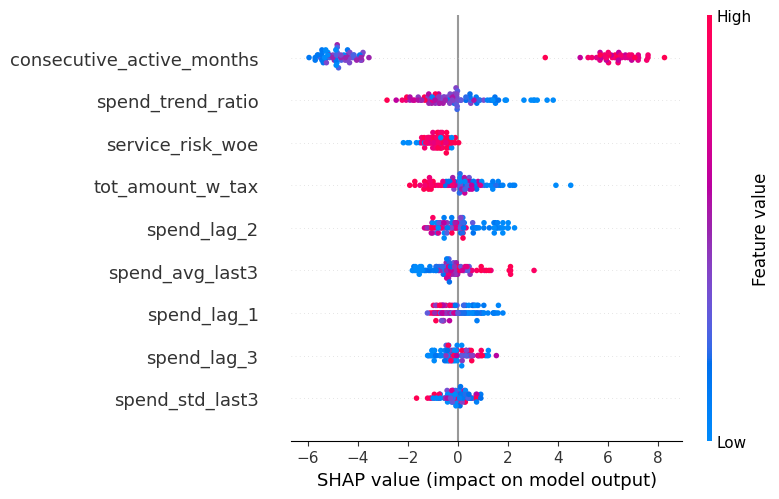

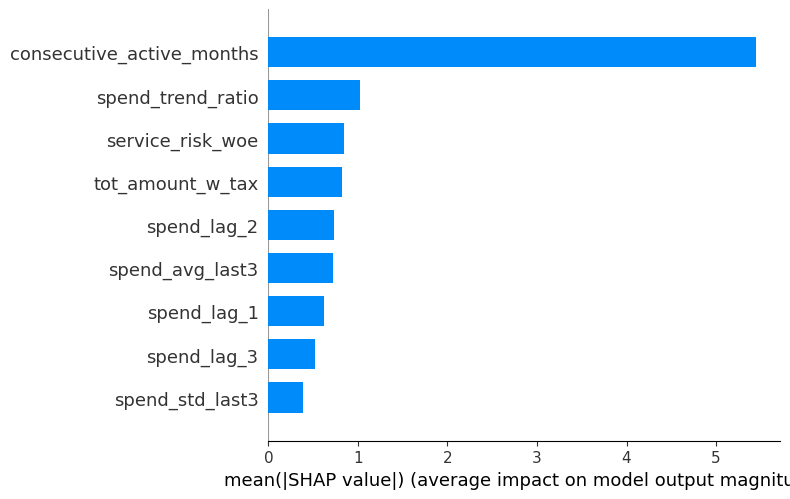

In [44]:
# # Use REAL validation set (recommended)
# shap_values = explainer(X_val_real) # Reduce this smaple of 100

# shap.summary_plot(shap_values, X_val_real)
# shap.summary_plot(shap_values, X_val_real, plot_type="bar")

#### Since time taken is High considerd only a sample ####

# Take a sample of 100 rows from the real validation set
X_val_sample = X_val_real.sample(n=100, random_state=42)

# Compute SHAP values only for that sample
shap_values = explainer(X_val_sample)

# SHAP summary plots
shap.summary_plot(shap_values, X_val_sample)
shap.summary_plot(shap_values, X_val_sample, plot_type="bar")

18.3 Local explanation for a single validation sample

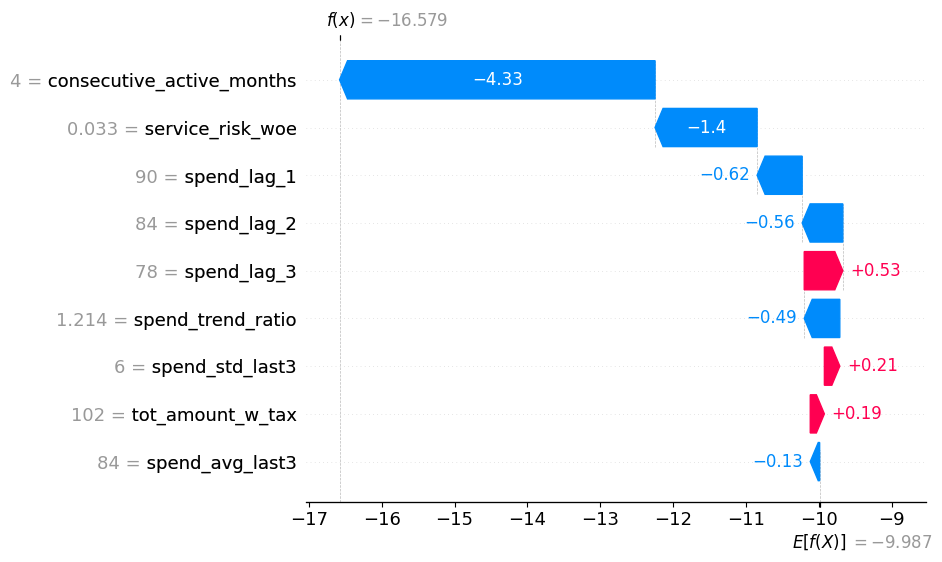

In [45]:
i = 0
shap.plots.waterfall(shap_values[i])

18.4 Explain top risky customer

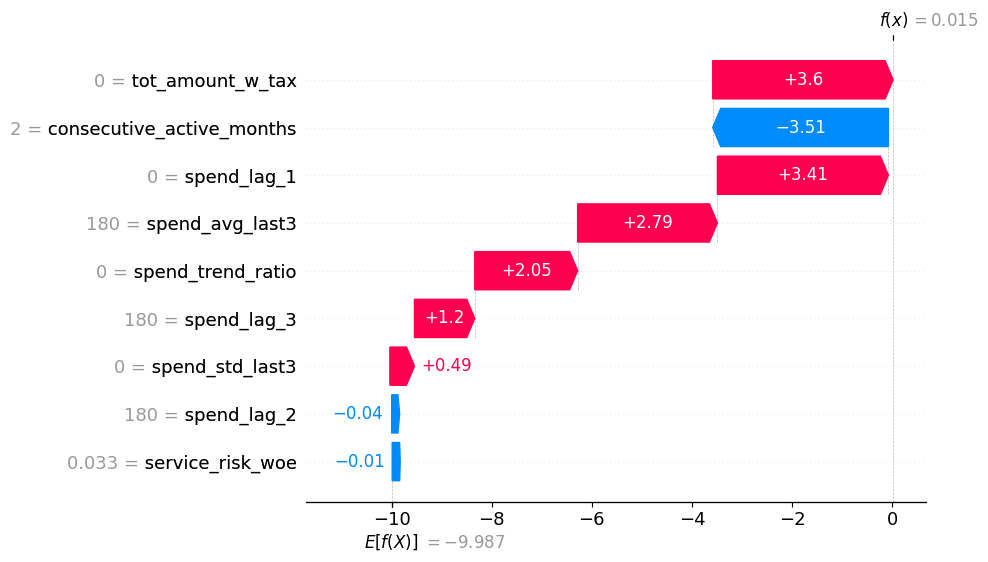

In [46]:
top_idx = score_df.sort_values("churn_probability", ascending=False).index[1]
top_customer_data = score_X.loc[top_idx:top_idx]

shap_values_top = explainer(top_customer_data)
shap.plots.waterfall(shap_values_top[0])

18.5 Feature interaction insight

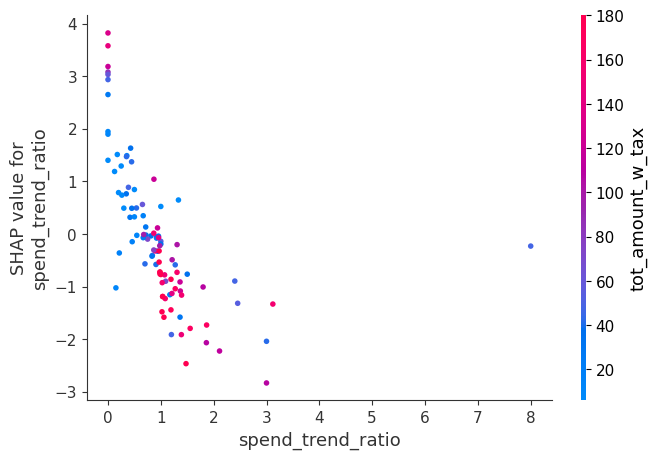

In [47]:
# shap.dependence_plot("spend_trend_ratio", shap_values.values, X_val_real) #### Changed to Sample ####

shap.dependence_plot("spend_trend_ratio", shap_values.values, X_val_sample)

**#### Get High risk Customers Who will get churn in 2026-02 ####**

In [48]:
# ================================
# Predict 2026-02 churn using 2026-01 non-churn customers
# with tuned CatBoost model
# ================================

# Use tuned model and threshold
best_model_ctgan = cat_model_tuned
best_threshold_ctgan = cat_best_t_tuned

# Base month = customer status month
base_month = pd.Period("2026-01", freq="M")

# Predicted churn month = next month
pred_month = base_month + 1

# Select 2026-01 customers who are currently non-churn
jan_nonchurn_df = df_long[
    (df_long["MONTH_PRD"] == base_month) &
    (df_long["churn_flag"] == 0)
].copy()

print("Base month (input month)                :", base_month)
print("Predicted churn month (output month)    :", pred_month)
print("Total non-churn customers in base month :", jan_nonchurn_df.shape[0])

if jan_nonchurn_df.empty:
    print("No non-churn customers found for the base month.")
else:
    # Prepare feature matrix
    jan_nonchurn_X = jan_nonchurn_df[features].copy()

    # Numeric safety
    for col in features:
        jan_nonchurn_X[col] = pd.to_numeric(jan_nonchurn_X[col], errors="coerce")

    jan_nonchurn_X = jan_nonchurn_X.fillna(0)

    # Predict churn probability for next month
    jan_nonchurn_df["predicted_churn_probability"] = best_model_ctgan.predict_proba(jan_nonchurn_X)[:, 1]
    jan_nonchurn_df["predicted_churn_flag"] = (
        jan_nonchurn_df["predicted_churn_probability"] >= best_threshold_ctgan
    ).astype(int)

    # Assign the prediction month
    jan_nonchurn_df["PREDICTED_FOR_MONTH"] = pred_month

    # Keep only customers predicted to churn next month
    predicted_churn_customers_2026_02 = jan_nonchurn_df[
        jan_nonchurn_df["predicted_churn_flag"] == 1
    ].copy()

    print("Predicted churn customers for", pred_month, ":", predicted_churn_customers_2026_02.shape[0])

    display_cols = [
        c for c in [
            "MSISDN",
            "SERVICE_NAME",
            "MONTH_PRD",
            "PREDICTED_FOR_MONTH",
            "churn_flag",
            "predicted_churn_probability",
            "predicted_churn_flag"
        ] if c in predicted_churn_customers_2026_02.columns
    ]

    print("\nTop predicted churn customers for next month:")
    print(
        predicted_churn_customers_2026_02[display_cols]
        .sort_values("predicted_churn_probability", ascending=False)
        .head(20)
    )

Base month (input month)                : 2026-01
Predicted churn month (output month)    : 2026-02
Total non-churn customers in base month : 4757
Predicted churn customers for 2026-02 : 22

Top predicted churn customers for next month:
          MSISDN                    SERVICE_NAME MONTH_PRD PREDICTED_FOR_MONTH  churn_flag  predicted_churn_probability  predicted_churn_flag
30796  767313031                          MYBIDS   2026-01             2026-02         0.0                     0.994151                     1
21402  763825846        SINDHU THAEGI WAESSA IVR   2026-01             2026-02         0.0                     0.971997                     1
69770  779626856              SALLI BUS GAME IVR   2026-01             2026-02         0.0                     0.958802                     1
9626   760364140  NETH FM LAKSHAPATHI WARAMA IVR   2026-01             2026-02         0.0                     0.958103                     1
368    740157530  NETH FM LAKSHAPATHI WARAMA IVR   20

**#### Save data into a CSV file ####**

In [49]:
predicted_churn_customers_2026_02[
    [c for c in [
        "MSISDN",
        "SERVICE_NAME",
        "MONTH_PRD",
        "PREDICTED_FOR_MONTH",
        "churn_flag",
        "predicted_churn_probability",
        "predicted_churn_flag"
    ] if c in predicted_churn_customers_2026_02.columns]
].to_csv("predicted_churn_customers_2026_02_with_service.csv", index=False)

print("File saved: predicted_churn_customers_2026_02_with_service.csv")

File saved: predicted_churn_customers_2026_02_with_service.csv


 **19) Behavioral Insights and Feature Relationship Analysis**

19.1 Relationship between consecutive active months and churn

In [50]:
print(
    df_long[['consecutive_active_months', 'churn_flag']]
    .groupby('consecutive_active_months')
    .mean()
)

                           churn_flag
consecutive_active_months            
1                            0.000000
2                            0.000000
3                            0.000000
4                            0.000000
5                            0.000000
6                            0.143893
7                            0.115025
8                            0.110663
9                            0.104230
10                           0.000000
11                           0.141935
12                           0.141935
13                           0.122137
14                           0.129771
15                           0.175439
16                           0.192982
17                           0.107527
18                           0.118280
19                           0.000000
20                           0.000000
21                           0.000000
22                           0.000000
23                           0.000000
24                           0.000000
25          

19.2 Bucket active months and re-check relationship

In [51]:
df_long['active_months_bucket'] = pd.cut(
    df_long['consecutive_active_months'],
    bins=[0, 3, 6, 12, 24],
    labels=['low', 'medium', 'high', 'very_high']
)

print(
    df_long[['active_months_bucket', 'churn_flag']]
    .groupby('active_months_bucket')
    .mean()
)

                      churn_flag
active_months_bucket            
low                     0.000000
medium                  0.047964
high                    0.110003
very_high               0.138329


/tmp/ipykernel_5837/588027024.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('active_months_bucket')


**20) Visualization and Model Evaluation**

20.1 Churn distribution

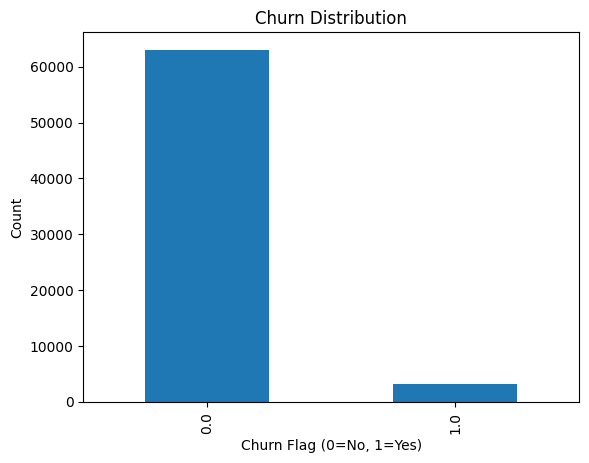

In [52]:
df_long['churn_flag'].value_counts().plot(kind='bar')
plt.title("Churn Distribution")
plt.xlabel("Churn Flag (0=No, 1=Yes)")
plt.ylabel("Count")
plt.show()

20.2 Churn rate over time

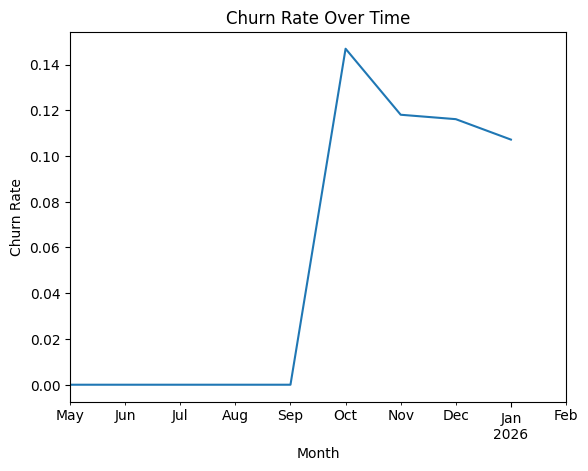

In [53]:
churn_trend = df_long.groupby('MONTH_PRD')['churn_flag'].mean()

churn_trend.plot()
plt.title("Churn Rate Over Time")
plt.xlabel("Month")
plt.ylabel("Churn Rate")
plt.show()

20.3 Activity bucket vs churn

/tmp/ipykernel_5837/4126841530.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_long.groupby('active_months_bucket')['churn_flag'].mean().plot(kind='bar')


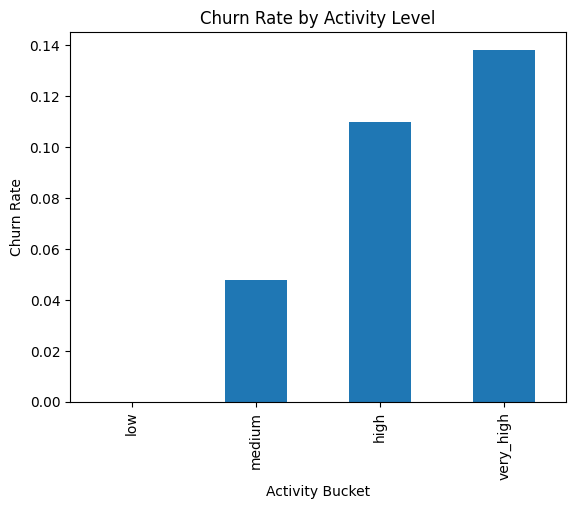

In [54]:
df_long.groupby('active_months_bucket')['churn_flag'].mean().plot(kind='bar')
plt.title("Churn Rate by Activity Level")
plt.xlabel("Activity Bucket")
plt.ylabel("Churn Rate")
plt.show()

20.4 Spend trend vs churn

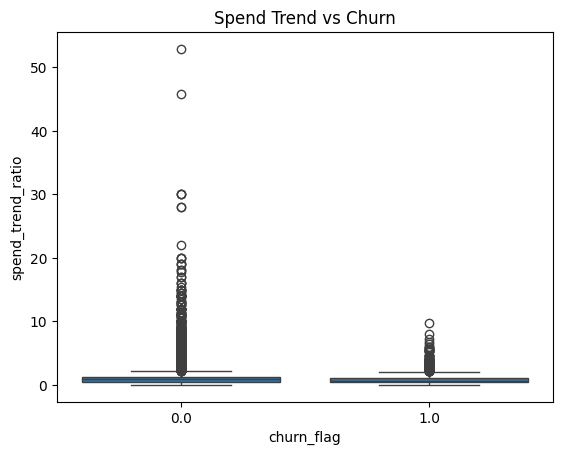

In [55]:
sns.boxplot(x='churn_flag', y='spend_trend_ratio', data=df_long)
plt.title("Spend Trend vs Churn")
plt.show()

20.5 Spend volatility vs churn

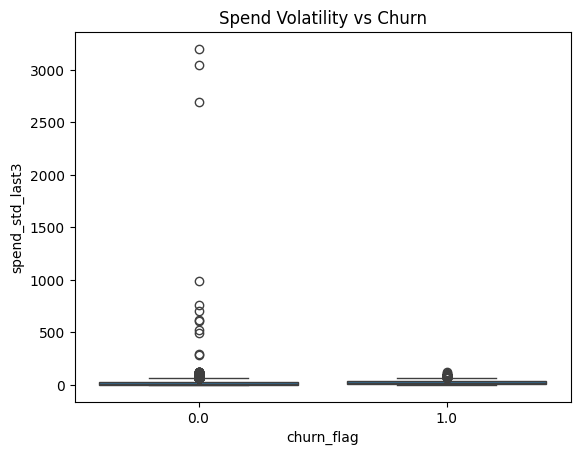

In [56]:
sns.boxplot(x='churn_flag', y='spend_std_last3', data=df_long)
plt.title("Spend Volatility vs Churn")
plt.show()

20.6 ROC curve for selected best model

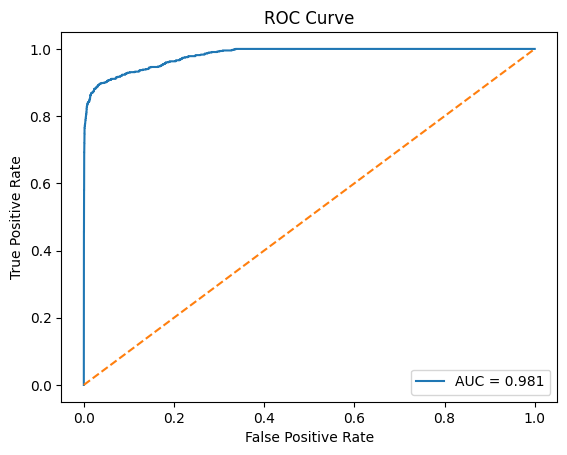

In [57]:
fpr, tpr, _ = roc_curve(y_val_real, cat_prob_tuned)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

20.7 Precision-Recall curve for selected best model

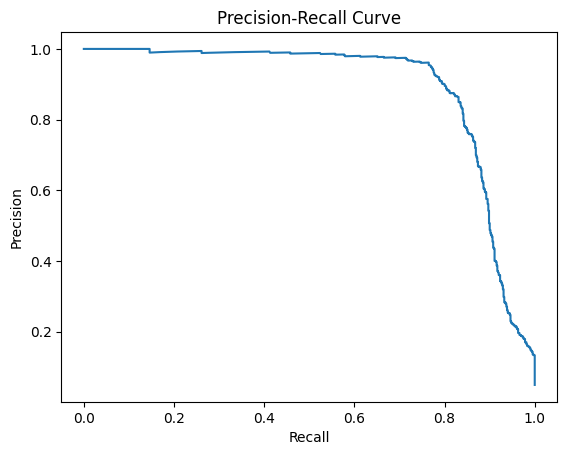

In [58]:
precision, recall, _ = precision_recall_curve(y_val_real, cat_prob_tuned)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve")
plt.show()

20.8 Confusion matrix for selected best model

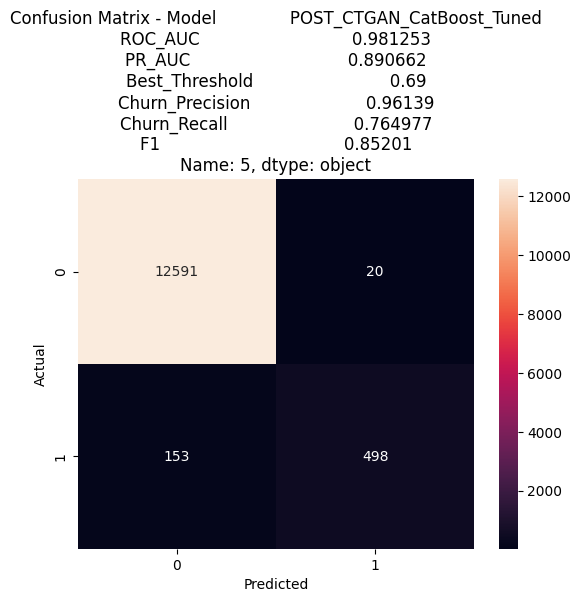

In [59]:
cm = confusion_matrix(y_val_real, (cat_prob_tuned >= best_threshold_ctgan).astype(int))

sns.heatmap(cm, annot=True, fmt='d')
plt.title(f"Confusion Matrix - {best}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

20.9 Risk segment distribution

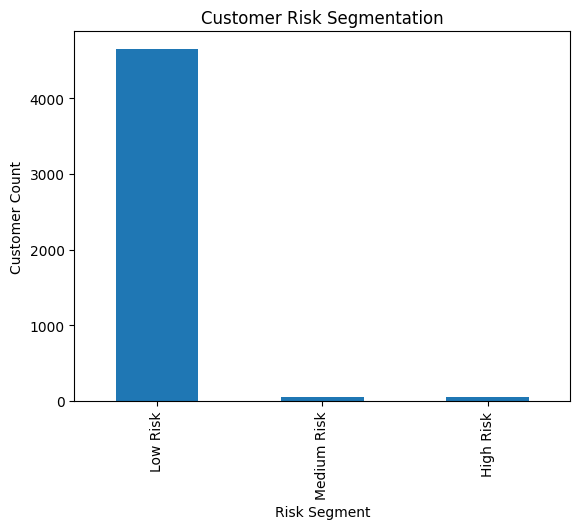

In [60]:
jan_nonchurn_df["risk_segment"] = pd.cut(
    jan_nonchurn_df["predicted_churn_probability"],
    bins=[0, 0.2, 0.5, 1.0],
    labels=["Low Risk", "Medium Risk", "High Risk"],
    include_lowest=True
)

jan_nonchurn_df["risk_segment"].value_counts().reindex(
    ["Low Risk", "Medium Risk", "High Risk"]
).plot(kind="bar")

plt.title("Customer Risk Segmentation")
plt.xlabel("Risk Segment")
plt.ylabel("Customer Count")
plt.show()

20.10 Churn probability distribution

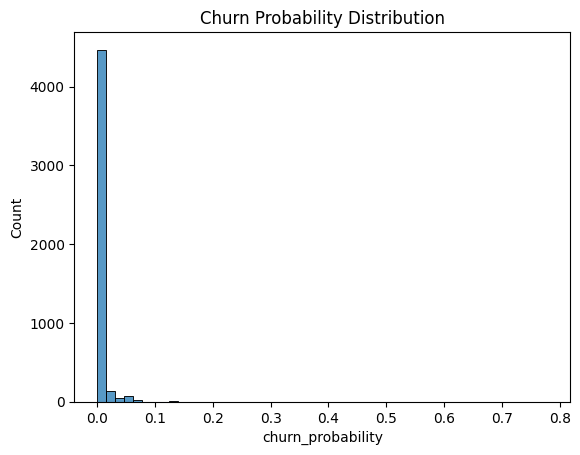

In [61]:
sns.histplot(score_df['churn_probability'], bins=50)
plt.title("Churn Probability Distribution")
plt.show()

**21) Interactive Prediction Tool**

21.1 Utility functions

In [62]:
def classify_risk(prob, threshold):
    if prob >= threshold:
        return "HIGH_RISK"
    # elif prob >= 0.60:
    #     return "MEDIUM_RISK"
    else:
        return "LOW_RISK"

def predict_customer_churn(input_data, model, threshold, features):
    df_input = pd.DataFrame([input_data])

    for col in features:
        if col not in df_input.columns:
            df_input[col] = 0

    df_input = df_input[features].copy()

    for col in features:
        df_input[col] = pd.to_numeric(df_input[col], errors='coerce')

    df_input = df_input.fillna(0)

    churn_probability = model.predict_proba(df_input)[:, 1][0]
    churn_prediction = int(churn_probability >= threshold)
    risk_segment = classify_risk(churn_probability, threshold)

    return {
        "churn_probability": float(churn_probability),
        "churn_prediction": churn_prediction,
        "risk_segment": risk_segment
    }

21.2 Manual model test

In [63]:
#Manual model test
test_customer = {
    'tot_amount_w_tax': 0.0,
    'spend_lag_1': 0.0,
    'spend_lag_2': 0.0,
    'spend_lag_3': 0.0,
    'spend_avg_last3': 0.0,
    'spend_std_last3': 0.0,
    'spend_trend_ratio': 0.0,
    'consecutive_active_months': 0,
    'service_risk_woe': 0.00
}

result = predict_customer_churn(
    input_data=test_customer,
    model=best_model_ctgan,
    threshold=best_threshold_ctgan,
    features=features
)

print(result)

{'churn_probability': 1.2304367673824139e-05, 'churn_prediction': 0, 'risk_segment': 'LOW_RISK'}


21.3 Widget-based input form

In [64]:
tot_amount_w_tax_w = widgets.FloatText(description='Current Spend:', value=30.0)
spend_lag_1_w = widgets.FloatText(description='Lag 1:', value=120.0)
spend_lag_2_w = widgets.FloatText(description='Lag 2:', value=108.0)
spend_lag_3_w = widgets.FloatText(description='Lag 3:', value=30.0)
spend_avg_last3_w = widgets.FloatText(description='Avg Last 3:', value=86.0)
spend_std_last3_w = widgets.FloatText(description='Std Last 3:', value=48.0)
spend_trend_ratio_w = widgets.FloatText(description='Trend Ratio:', value=0.35)
consecutive_active_months_w = widgets.IntText(description='Active Months:', value=4)
service_risk_woe_w = widgets.FloatText(description='Service WOE:', value=0.00)

predict_btn = widgets.Button(description='Predict Churn', button_style='danger')
output = widgets.Output()

def on_predict_clicked(b):
    with output:
        clear_output()

        customer_data = {
            'tot_amount_w_tax': tot_amount_w_tax_w.value,
            'spend_lag_1': spend_lag_1_w.value,
            'spend_lag_2': spend_lag_2_w.value,
            'spend_lag_3': spend_lag_3_w.value,
            'spend_avg_last3': spend_avg_last3_w.value,
            'spend_std_last3': spend_std_last3_w.value,
            'spend_trend_ratio': spend_trend_ratio_w.value,
            'consecutive_active_months': consecutive_active_months_w.value,
            'service_risk_woe': service_risk_woe_w.value
        }

        result = predict_customer_churn(
            input_data=customer_data,
            model=best_model_ctgan,
            threshold=best_threshold_ctgan,
            features=features
        )

        prediction_label = "CHURN" if result["churn_prediction"] == 1 else "NON-CHURN"

        display(Markdown("## Prediction Result"))
        display(Markdown(f"**Churn Probability:** {result['churn_probability']:.4f}"))
        display(Markdown(f"**Prediction:** {prediction_label}"))
        display(Markdown(f"**Risk Segment:** {result['risk_segment']}"))

predict_btn.on_click(on_predict_clicked)

form = widgets.VBox([
    widgets.HTML("<h3>Customer Churn Prediction Form</h3>"),
    tot_amount_w_tax_w,
    spend_lag_1_w,
    spend_lag_2_w,
    spend_lag_3_w,
    spend_avg_last3_w,
    spend_std_last3_w,
    spend_trend_ratio_w,
    consecutive_active_months_w,
    service_risk_woe_w,
    predict_btn,
    output
])

display(form)